# **Polynomial Regression with SciKit-Learn**

Previously, we explored how to fit a simple best-fit line. Now, we’ll expand our toolkit to tackle more complex scenarios!

We'll use `PolynomialFeatures` from `sklearn.preprocessing` to transform our original dataset by adding polynomial features. This allows us to model non-linear relationships using a linear regression model.  

## **Polynomial Regression**

Polynomial regression is a type of linear regression analysis used to model non-linear relationships between a dependent variable (y) and independent variables (X) by fitting a curve, rather than a straight line, to the data.


Starting from the simple linear equation (assuming just one feature `x`):

$$\hat{y} = \beta_0 + \beta_1 x_1$$

we can generate additional polynomial features for a chosen degree *d*:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_1^2 + \dots + \beta_d x_1^d$$

Once transformed, we can fit a linear regression model to these new features. Essentially, $x^2, x^3, ..., x^d$ are treated as **new input features**, so linear regression can model complex, non-linear trends.

**Important note:** In practice, `PolynomialFeatures` will also generate **interaction terms** between features.  

For example, if a sample has two features $[a, b]$, the degree-2 polynomial transformation will produce: $$[1, a, b, a^2, a*b, b^2]$$


Here, $a*b$ represents the interaction between features. This allows the model to capture relationships not only between individual features and the target but also between combinations of features.

## **Why Use Polynomial Regression Instead of Simple Linear Regression?**

- Simple linear regression assumes a **straight-line relationship**, which is often too limiting.
- Polynomial regression helps address **two key issues**:
  - **Non-linear relationships** between features and the target.
  - **Interaction terms** between features (how features influence the target *together*).


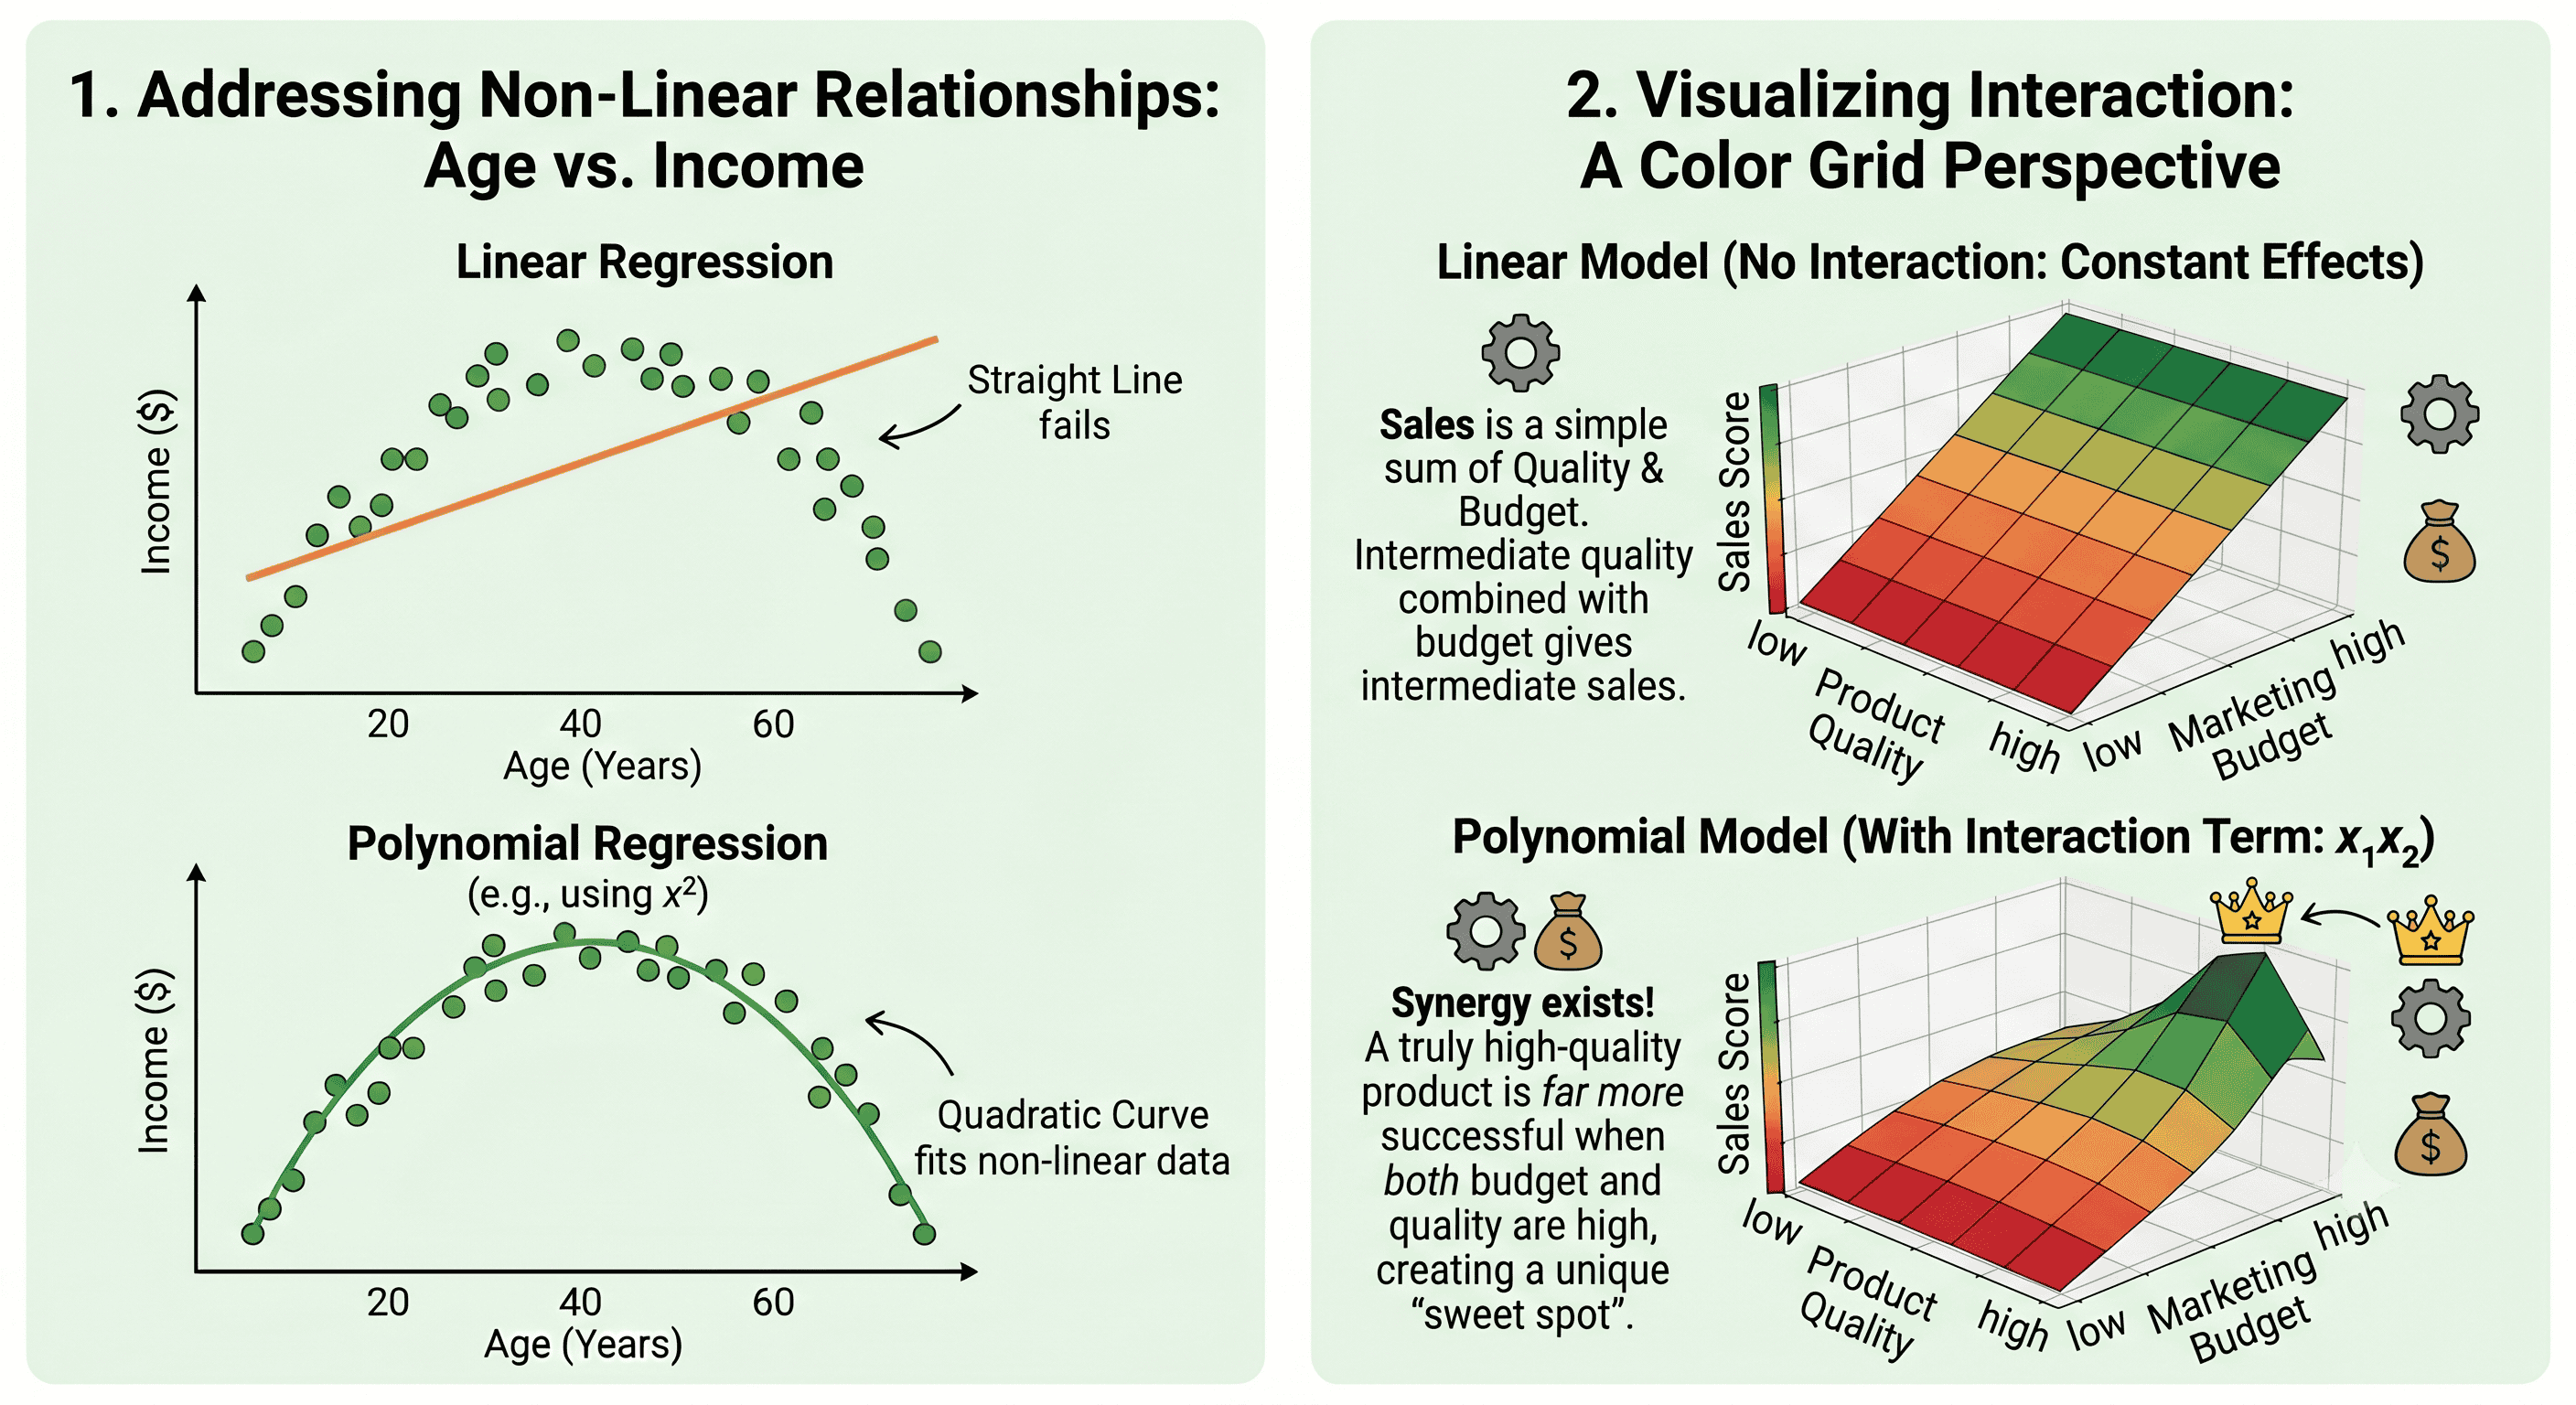

- By adding polynomial and interaction terms (e.g., \(x^2\), \(x_1 x_2\)), the model can capture more complex patterns.
- We still use **linear regression**; only the feature space is expanded.
- Increased flexibility improves expressiveness but raises the risk of **overfitting**, making model evaluation essential.

<br>

## **Why Polynomial Regression is Still 'Linear'**

The key to understanding why polynomial regression is classified as a *linear* model lies in how we define "linear." In the context of regression, a model is considered linear if it is linear in its **parameters (coefficients)**, not necessarily linear in the independent variables (features).

Let's break down the equation again:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_1^2 + \dots + \beta_d x_1^d$$

Here's why it's linear in parameters:

1.  **Linearity in Coefficients ($\beta$)**: Each term in the equation is multiplied by a coefficient ($\beta_0, \beta_1, \beta_2$, etc.), and these coefficients appear in a linear fashion (i.e., they are not raised to any power, multiplied by each other, or part of a non-linear function like `log(β)` or `sin(β)`).

2.  **Transformed Features**: While the original feature `x` is raised to powers (e.g., $x_1^2, x_1^3$), these transformed terms ($x_1, x_1^2, \dots, x_1^d$) are treated as new, distinct features by the linear regression algorithm. If you imagine replacing $x_1$ with $z_1$, $x_1^2$ with $z_2$, and so on, the equation becomes:

    $$\hat{y} = \beta_0 + \beta_1 z_1 + \beta_2 z_2 + \dots + \beta_d z_d$$

    This equation clearly shows a linear combination of the new features ($z_1, z_2, \dots, z_d$) with their respective coefficients ($\beta_1, \beta_2, \dots, \beta_d$). The underlying model is still finding the best linear combination of these *transformed* features.

**Analogy**: Think of it like this: if you have a calculator and you want to find the value of `2 * A + 3 * B`, that's a linear operation. Now, if `A` happens to be `x` and `B` happens to be `x^2`, the original input `x` might be non-linear in its effect, but the operation of multiplying `A` by 2 and `B` by 3 and summing them is still a linear operation on `A` and `B`.

**In essence**: Polynomial regression extends the capabilities of linear regression to model non-linear data patterns by creating non-linear combinations of the *original features* (like $x^2$, $x*y$), but it always fits a model that is linear with respect to the *weights/coefficients* assigned to those (potentially transformed) features. This allows us to use the same optimization techniques and interpretations associated with linear models.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Load & Inspect the Dataset**

In [ ]:
df = pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# **Feature / Label Separation**

X = features (independent variables)

y = label (dependent variable)

In [ ]:
X = df.drop("sales", axis=1)
y = df["sales"]

## **Polynomial Features**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_converter = PolynomialFeatures(degree=2,include_bias=False)

# Converter "fits" to data, in this case, reads in every X column
# Then it "transforms" and ouputs the new polynomial data
poly_features = polynomial_converter.fit_transform(X)

poly_features.shape

(200, 9)

### What is `include_bias` in `PolynomialFeatures`?

When using `PolynomialFeatures`, the `include_bias` parameter controls whether a bias term (an intercept term, typically represented as a column of ones) is generated as part of the transformed features.

*   **`include_bias=True` (Default)**:
    *   This is the default behavior. `PolynomialFeatures` will add a column of ones to the beginning of the transformed feature matrix. This column represents the intercept term ($\beta_0$) in a linear model.
    *   For an input `[a, b]`, with `degree=2`, the output features would be `[1, a, b, a^2, a*b, b^2]`.
    *   You typically want to keep `include_bias=True` when your subsequent linear model (e.g., `LinearRegression`) is initialized with `fit_intercept=False`.
    *   If you use `LinearRegression(fit_intercept=True)` (which is the default) along with `PolynomialFeatures(include_bias=True)`, your model will effectively have *two* intercept terms (one generated by `PolynomialFeatures` and another added internally by `LinearRegression`), leading to multicollinearity and potentially making the coefficients harder to interpret, though it won't necessarily break the model.

*   **`include_bias=False`**:
    *   This tells `PolynomialFeatures` *not* to add the column of ones (the bias/intercept term) to the transformed feature matrix.
    *   For an input `[a, b]`, with `degree=2`, the output features would be `[a, b, a^2, a*b, b^2]`.
    *   You typically set `include_bias=False` when your subsequent linear model (e.g., `LinearRegression`) is initialized with `fit_intercept=True` (which is the default).
    *   In this scenario, `LinearRegression` will internally handle the intercept term, avoiding redundancy.

**In summary**: The goal is to have *one and only one* intercept term in your final model. Most scikit-learn linear models handle the intercept by default (`fit_intercept=True`). Therefore, it is common practice to set `include_bias=False` in `PolynomialFeatures` to avoid generating a redundant bias term that the linear model would otherwise add itself.

In [ ]:
X.shape

(200, 3)

In [ ]:
X.iloc[0]

,0
TV,230.1
radio,37.8
newspaper,69.2


In [ ]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

### **Difference between `.fit_transform(X)`, `.fit(X)`, and `.transform(X)` in scikit-learn**


#### `.fit(X[, y])`
- **Learns parameters from the data**
- Does **not** modify the data yet

Examples:
- `StandardScaler.fit` → computes mean & standard deviation
- `PolynomialFeatures.fit` → decides which polynomial terms to create
- `PCA.fit` → learns principal directions


#### `.transform(X)`
- **Applies the learned transformation**
- Uses parameters computed during `.fit`

Examples:
- subtract mean, divide by std
- generate polynomial features
- project onto PCA axes



#### `.fit_transform(X)`

**`.fit_transform(X)` = `.fit(X)` + `.transform(X)` in one call**  

- Convenience method
- Equivalent to:

```python
transformer.fit(X)
X_new = transformer.transform(X)
```
<br>

**BUT** *when and where* you call them matters a lot (especially for ML correctness).


| Method           | When to call           | Why                                                       |
| ---------------- | ---------------------- | --------------------------------------------------------- |
| `.fit`           | Training data only     | Learn parameters without touching test data               |
| `.transform`     | Both training and test | Apply learned transformation consistently                 |
| `.fit_transform` | Training data only     | Learn parameters **and** apply transformation in one step |



<br><br>

## **Train_Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

## **Model Creation & Training**

- Estimator = untrained model
- .fit() performs learning (gradient descent internally)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## **Predictions on Test Data**

Never evaluate on training data

In [ ]:
test_predictions = model.predict(X_test)

## **Regression Metrics**





In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

MAE = mean_absolute_error(y_test,test_predictions)
print(MAE)
MSE = mean_squared_error(y_test,test_predictions)
print(MSE)
RMSE = np.sqrt(MSE)
print(RMSE)

0.4896798044803838
0.4417505510403753
0.6646431757269274


#### **Comparison with Simple Linear Regression**

1.213745773614481
2.2987166978863796
1.5161519375993884


## **Choosing Degree of Polynomial**

### **Adjusting Model Complexity**

Are we happy with the model's current performance? Sometimes increasing the polynomial degree can improve the fit, but how high is too high? Choosing the right complexity is critical — too low, and the model **underfits**; too high, and it **overfits**.  

**Underfitting** happens when a model is too simple and performs poorly on both training and test data.

**Overfitting** happens when a model is too complex, fits the training data very well but fails to generalize to new data.

We can experiment with different polynomial degrees to see their effect on both training and test performance. This hands-on exploration will naturally lead us into a discussion on **overfitting** and **underfitting**.

We will use a `for` loop to:

1. Generate polynomial features of varying degrees from the original dataset.  
2. Split each transformed dataset into **training** and **testing** sets.  
3. Fit a linear regression model on the training data.  
4. Evaluate and record metrics (e.g., RMSE, R²) on **both** the training and testing sets.  
5. Plot the training and test errors versus polynomial degree to visualize the trade-off between underfitting and overfitting.  

By comparing the errors for different degrees, we can see how the model becomes too flexible at higher degrees — capturing noise in the training data instead of the underlying trend. This will give us a clear intuition for **selecting the optimal model complexity**.

In [ ]:
# TRAINING ERROR PER DEGREE
train_rmse_errors = []
# TEST ERROR PER DEGREE
test_rmse_errors = []

for d in range(1,10):

    # CREATE POLY DATA SET FOR DEGREE "d"
    polynomial_converter = PolynomialFeatures(degree=d,include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)

    # SPLIT THIS NEW POLY DATA SET
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

    # TRAIN ON THIS NEW POLY SET
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train,y_train)

    # PREDICT ON BOTH TRAIN AND TEST
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Calculate Errors

    # Errors on Train Set
    train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))

    # Errors on Test Set
    test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))

    # Append errors to lists for plotting later


    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

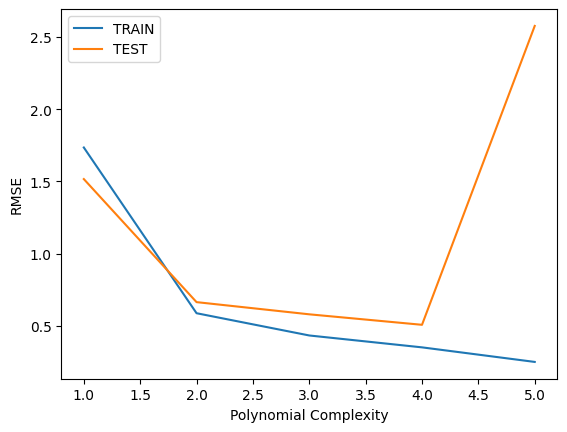

In [ ]:
plt.plot(range(1,6),train_rmse_errors[:5],label='TRAIN')
plt.plot(range(1,6),test_rmse_errors[:5],label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

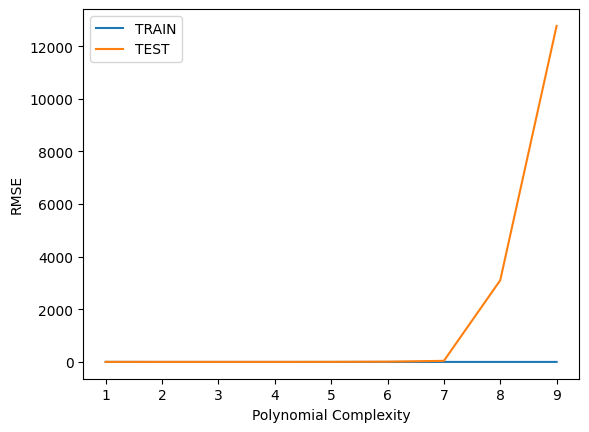

In [ ]:
plt.plot(range(1,10),train_rmse_errors,label='TRAIN')
plt.plot(range(1,10),test_rmse_errors,label='TEST')
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()

## **Finalizing Model Choice**

There are now 2 things we need to save, the Polynomial Feature creator AND the model itself. Let's explore how we would proceed from here:

1. Choose final parameters based on test metrics
2. Retrain on all data
3. Save Polynomial Converter object
4. Save model

In [ ]:
# Based on our chart, could have also been degree=4, but
# it is better to be on the safe side of complexity
final_poly_converter = PolynomialFeatures(degree=3,include_bias=False)

final_model = LinearRegression()

final_model.fit(final_poly_converter.fit_transform(X),y)

LinearRegression()

In [ ]:
from joblib import dump, load

dump(final_model, 'sales_poly_model.joblib')

['sales_poly_model.joblib']

In [ ]:
dump(final_poly_converter,'poly_converter.joblib')

['poly_converter.joblib']

## **Prediction on New Data**

In [ ]:
loaded_poly = load('poly_converter.joblib')
loaded_model = load('sales_poly_model.joblib')

In [ ]:
campaign = [[149,22,12]]

In [ ]:
campaign_poly = loaded_poly.transform(campaign)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [ ]:
campaign_poly

array([[1.490000e+02, 2.200000e+01, 1.200000e+01, 2.220100e+04,
        3.278000e+03, 1.788000e+03, 4.840000e+02, 2.640000e+02,
        1.440000e+02, 3.307949e+06, 4.884220e+05, 2.664120e+05,
        7.211600e+04, 3.933600e+04, 2.145600e+04, 1.064800e+04,
        5.808000e+03, 3.168000e+03, 1.728000e+03]])

In [ ]:
final_model.predict(campaign_poly)

array([14.64501014])